# P1 ELECCION Y DESCRIPCION DEL CORPUS 
Para este proyecto se ha conformado un corpus de 61 documentos de texto, obtenidos de fuentes públicas y de acceso abierto. El tema central es la participación de Palantir Technologies en el conflicto de Gaza, analizado desde tres perspectivas distintas para asegurar una estructura semántica rica:


**Corporativo (11 documentos):** Textos oficiales de Palantir, cartas a inversionistas y comunicados de prensa sobre alianzas estratégicas (como con Oracle o el Ejército de EE. UU.). Estos documentos aportan el lenguaje técnico y empresarial.

**Crítico (19 documentos):** Reportes de ONGs y organismos de derechos humanos (Amnistía Internacional, Human Rights Watch, BDS) que cuestionan el uso ético de la IA y posibles crímenes de guerra.

**Prensa (31 documentos):** Cobertura de medios internacionales (Reuters, The Guardian, AP News, Al Jazeera) que ofrecen una visión mediática y de investigación sobre el impacto de la tecnología en el terreno

# NUESTRO INTERES SOBRE ESTE CORPUS
El valor de este corpus radica en la tensión entre la narrativa de eficiencia técnica de Palantir, la denuncia de organismos internacionales y la cobertura mediática global. Al incluir una categoría de Prensa además de la Corporativa y Crítica, el estudio busca determinar si el análisis matemático (SVD) logra identificar al periodismo como un 'puente' semántico o si este se inclina hacia alguno de los otros dos discursos.

# P2 HIPOTESIS INICIAL
Para este análisis, nuestra hipótesis es que el algoritmo SVD va a lograr identificar tres posturas o "tonos" diferentes en los textos, basándose en las palabras que usa cada grupo:

**El grupo Corporativo:** Esperamos que se agrupe en un extremo del gráfico. Su lenguaje debería estar lleno de términos sobre negocios, eficiencia y tecnología, como partnership (alianza), AI, defense, interoperability y growth. Será un discurso muy técnico y enfocado en resultados.

**El grupo Crítico:** Esperamos que se ubique en el extremo opuesto al corporativo. Aquí el vocabulario será de denuncia y derechos humanos, con palabras frecuentes como war crimes (crímenes de guerra), complicity, genocide, surveillance y human rights.

**El grupo de Prensa:** Esta es la parte más interesante. Creemos que los artículos de prensa (Reuters, The Guardian, BBC) no se van a ir a un solo extremo, sino que aparecerán distribuidos en el centro o más dispersos. Al ser periodismo, tienen que usar tanto los términos técnicos de Palantir como las acusaciones de las ONGs para informar.

# P3 Preprocesamiento del texto

Para limpiar los datos y construir un vocabulario útil, aplicamos un proceso de procesamiento de lenguaje natural (NLP) sobre los 61 documentos. Las decisiones tomadas fueron:

**Normalización:** Convertimos todo el texto a minúsculas y eliminamos caracteres especiales, números y signos de puntuación. Esto evita que el algoritmo trate a "Palantir" y "palantir" como palabras distintas.

**Eliminación de Stopwords:** Filtramos las palabras vacías del inglés (usando la librería nltk), eliminando términos como the, and, of, for, que aparecen con mucha frecuencia pero no aportan contenido semántico al análisis de temas.

**Tokenización:** Dividimos los textos en unidades mínimas (palabras) para construir la matriz de términos.

**TF-IDF:** En lugar de solo contar palabras, decidimos usar TF-IDF. Esto es clave porque ayuda a resaltar palabras que son importantes en un documento específico pero que no aparecen en todos los textos (como "genocide" en los críticos o "interoperability" en los corporativos), dándoles más peso matemático.

# P4. Construcción de la matriz textual

Para el análisis textual, decidimos trabajar con una matriz término-documento siguiendo la convención de la clase. Dado que la librería de vectorización utilizada entrega por defecto una matriz con los documentos en las filas y los términos en las columnas , se transpuso el resultado.  La matriz final construida es A perteneciente a los Reales , donde las filas representan a los $m = 6970$ términos únicos del vocabulario y las columnas representan a los $n = 41$ documentos del corpus.  Para el cálculo de los pesos se utilizó TF-IDF. Por lo tanto, una entrada $A_{ij}$ en la matriz  representa la importancia relativa del término $i$ en el documento $j$. Este valor es alto si el término aparece con alta frecuencia en ese documento específico (TF), pero es penalizado si la palabra es demasiado común en el resto del corpus (IDF), permitiendo así destacar el vocabulario que realmente aporta significado semántico a cada texto.

# P5 Calculo de la SVD  

A partir de la matriz término-documento $A$, calculamos su Descomposición en Valores Singulares (SVD), obteniendo la factorización $A = U\Sigma V^T$.  
En el contexto de nuestro corpus de Palantir, cada una de estas componentes nos entrega información semántica fundamental:
* Valores singulares (diagonal de $\Sigma$): Representan la "importancia" o la cantidad de varianza que captura cada concepto latente (o tema) descubierto en el corpus. Los valores más altos corresponden a los patrones semánticos más dominantes en los textos.
* Vectores singulares izquierdos (columnas de $U$): Describen las direcciones principales en el espacio de los términos. Nos indican qué palabras tienden a co-ocurrir y, por ende, qué términos construyen cada uno de los conceptos latentes.
* Vectores singulares derechos (columnas de $V$, o filas de $V^T$): Describen las direcciones principales en el espacio de los documentos. Representan las coordenadas de cada texto y nos indican qué tanto trata cada documento sobre los distintos temas descubiertos.

# P6 Valores singulares y eleccion de K

Para determinar cuántas componentes capturan la estructura principal del corpus, graficamos los valores singulares obtenidos de la matriz diagonal $\Sigma$.
Al observar el decaimiento de los valores singulares en el gráfico, notamos una caída abrupta en las primeras componentes.
El primer valor singular es significativamente mayor al resto, y la curva presenta un descenso pronunciado hasta llegar aproximadamente a la quinta componente.
A partir de este punto, comienza a estabilizarse, mostrando un decaimiento mucho más lento y marginal.
Por lo tanto, elegimos una dimensión reducida de  **$k = 6$** . Esta elección es razonable porque nos permite conservar la estructura semántica principal latente en los textos, filtrando el "ruido" asociado a las componentes menores que aportan poca varianza y representan variaciones irrelevantes o uso de palabras muy esporádicas en el corpus.

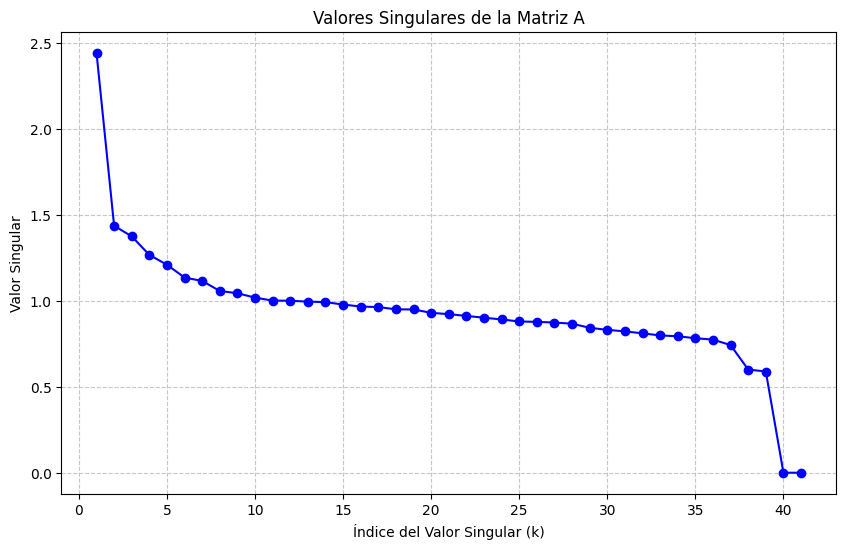

# P7 Representacion de documentos y terminos en baja dimension

### El eje Y
El eje y, es decir el componente principal 2 está dividiendo la información de nuestro corpus evidentemente en dos mundos con vocabularios totalmente distintos

- zona superior (Y positivo): Aqui se nota que hay un cluster muy denso, y a medida que aumentamos la cantidad de palabras se densifica más, las palabras como "military", "gaza", "surveullance", "genocide" se encuentran en esta parte de nuesto gradico. Este grupo creemos que representa claramente el rol que tiene la empresa Palantir en conflictos geopoliticos y contratos de defensa y seguridad. Es el escenario donde podemos cuestionar los sistemas sociotecnicos de esta empresa, para entender mejor las fuertes implicancias que tiene a nivel ético y social, ya nuestro modelo logro aislar la controversia algoritmica y militar en este cuadrante

- zona inferior (Y negativo): es el extremo opuesto al anterior, vemos terminos como "financials", "governance" y "resources". Este grupo nos representa el lado netamente corporativo, administrativo y burocratico.

### El eje X

- Podemos observar que la palabra Palantir está muy alejada hacia la izquierda, y la significancia de esto es que es el tema central que cruza la gran mayoria de los documentos en el corpus, por lo tanto, es tambien el tema que captura una mayor "varianza" o peso en la primera componente principal

Podemos entender los ejemplos siguientes como demostraciónes concretas de relaciones:

- La cercanía extrema entre "surveillance", "intelligence", "military" y los nombres de zonas de conflicto, como "gaza" confirmarian que, dentro de este corpus que hemos construido, la vigilancia tecnologíca y la recolección de datos se discuten de la mano con la inteligencia militar y no como una herramienta comercial sin implicaciones.
- Igualmente es revelador notar como la palabra "technologies" se ubica en el centro, funcionando como un puente entre las zonas, mientras que palabras como "fiancials" y "genocide" están en los extremos opuestos del gráfico. Esto nos indica que matematicamente podemos demostrar que los documentos que reportan el exito corporativo y financiero están a su vez aislando por completo el vocabulario relacionado con el impacto etico y humano de los conflicos armados en los que se ven involucrados

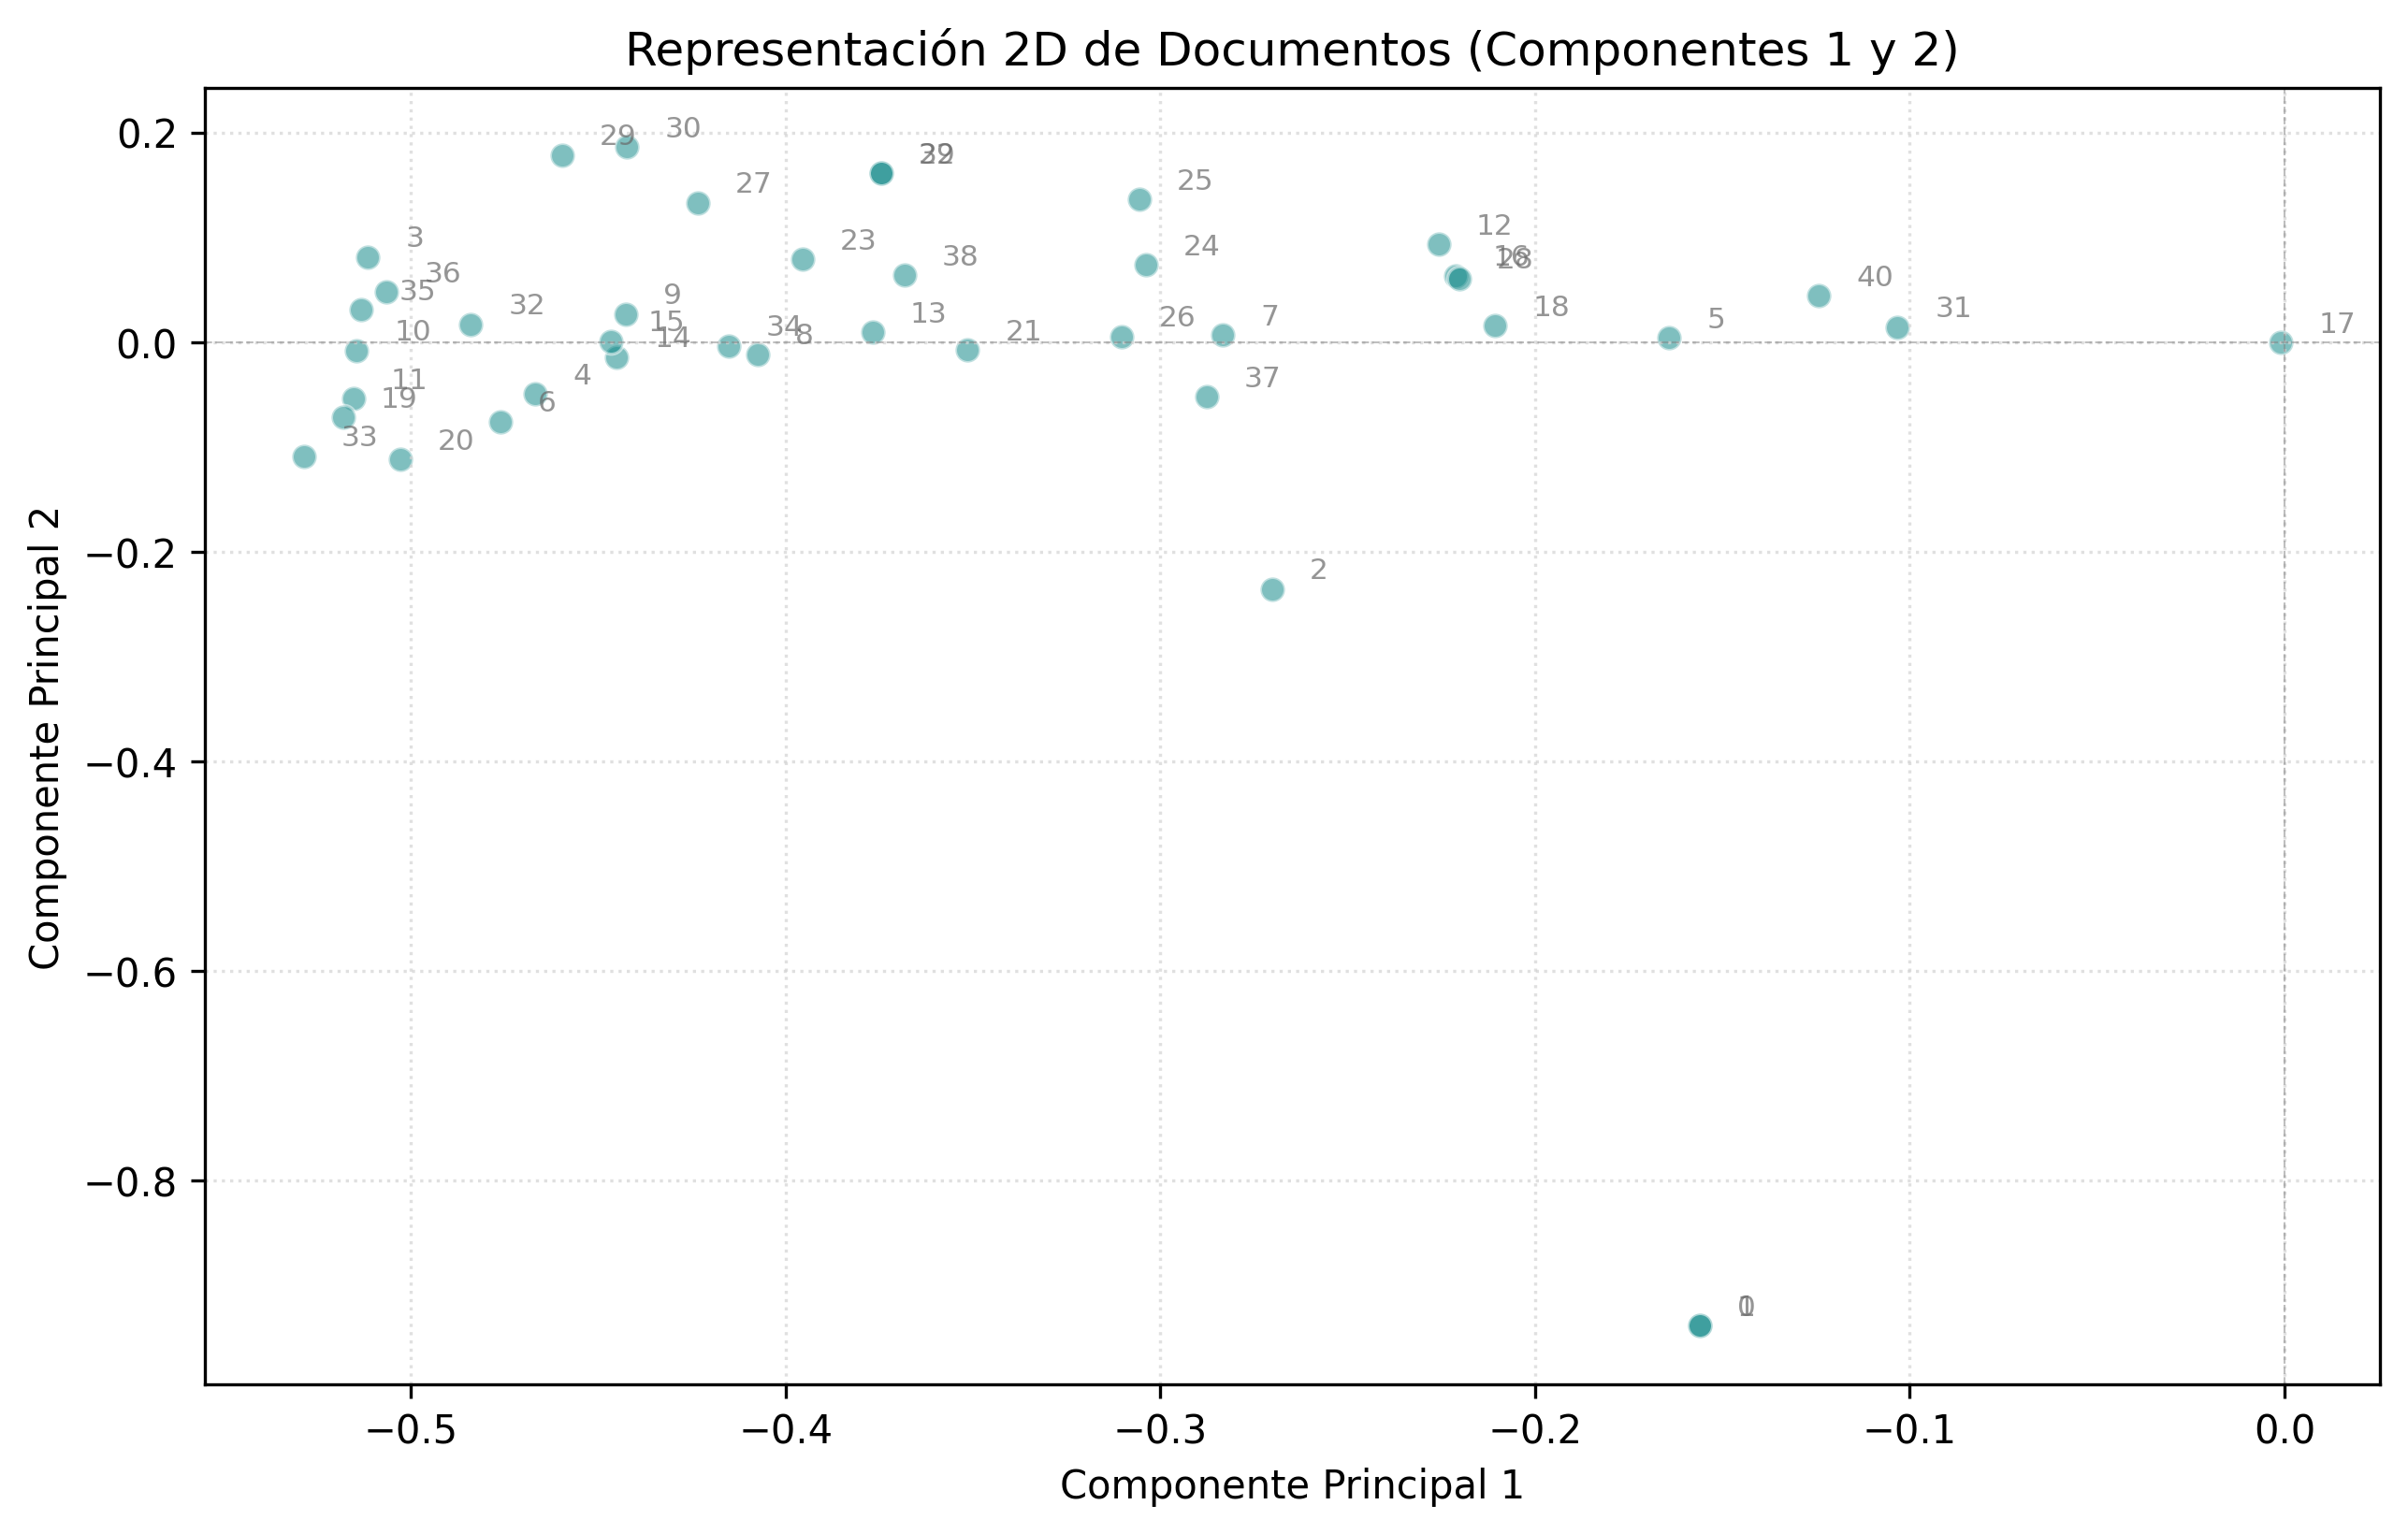

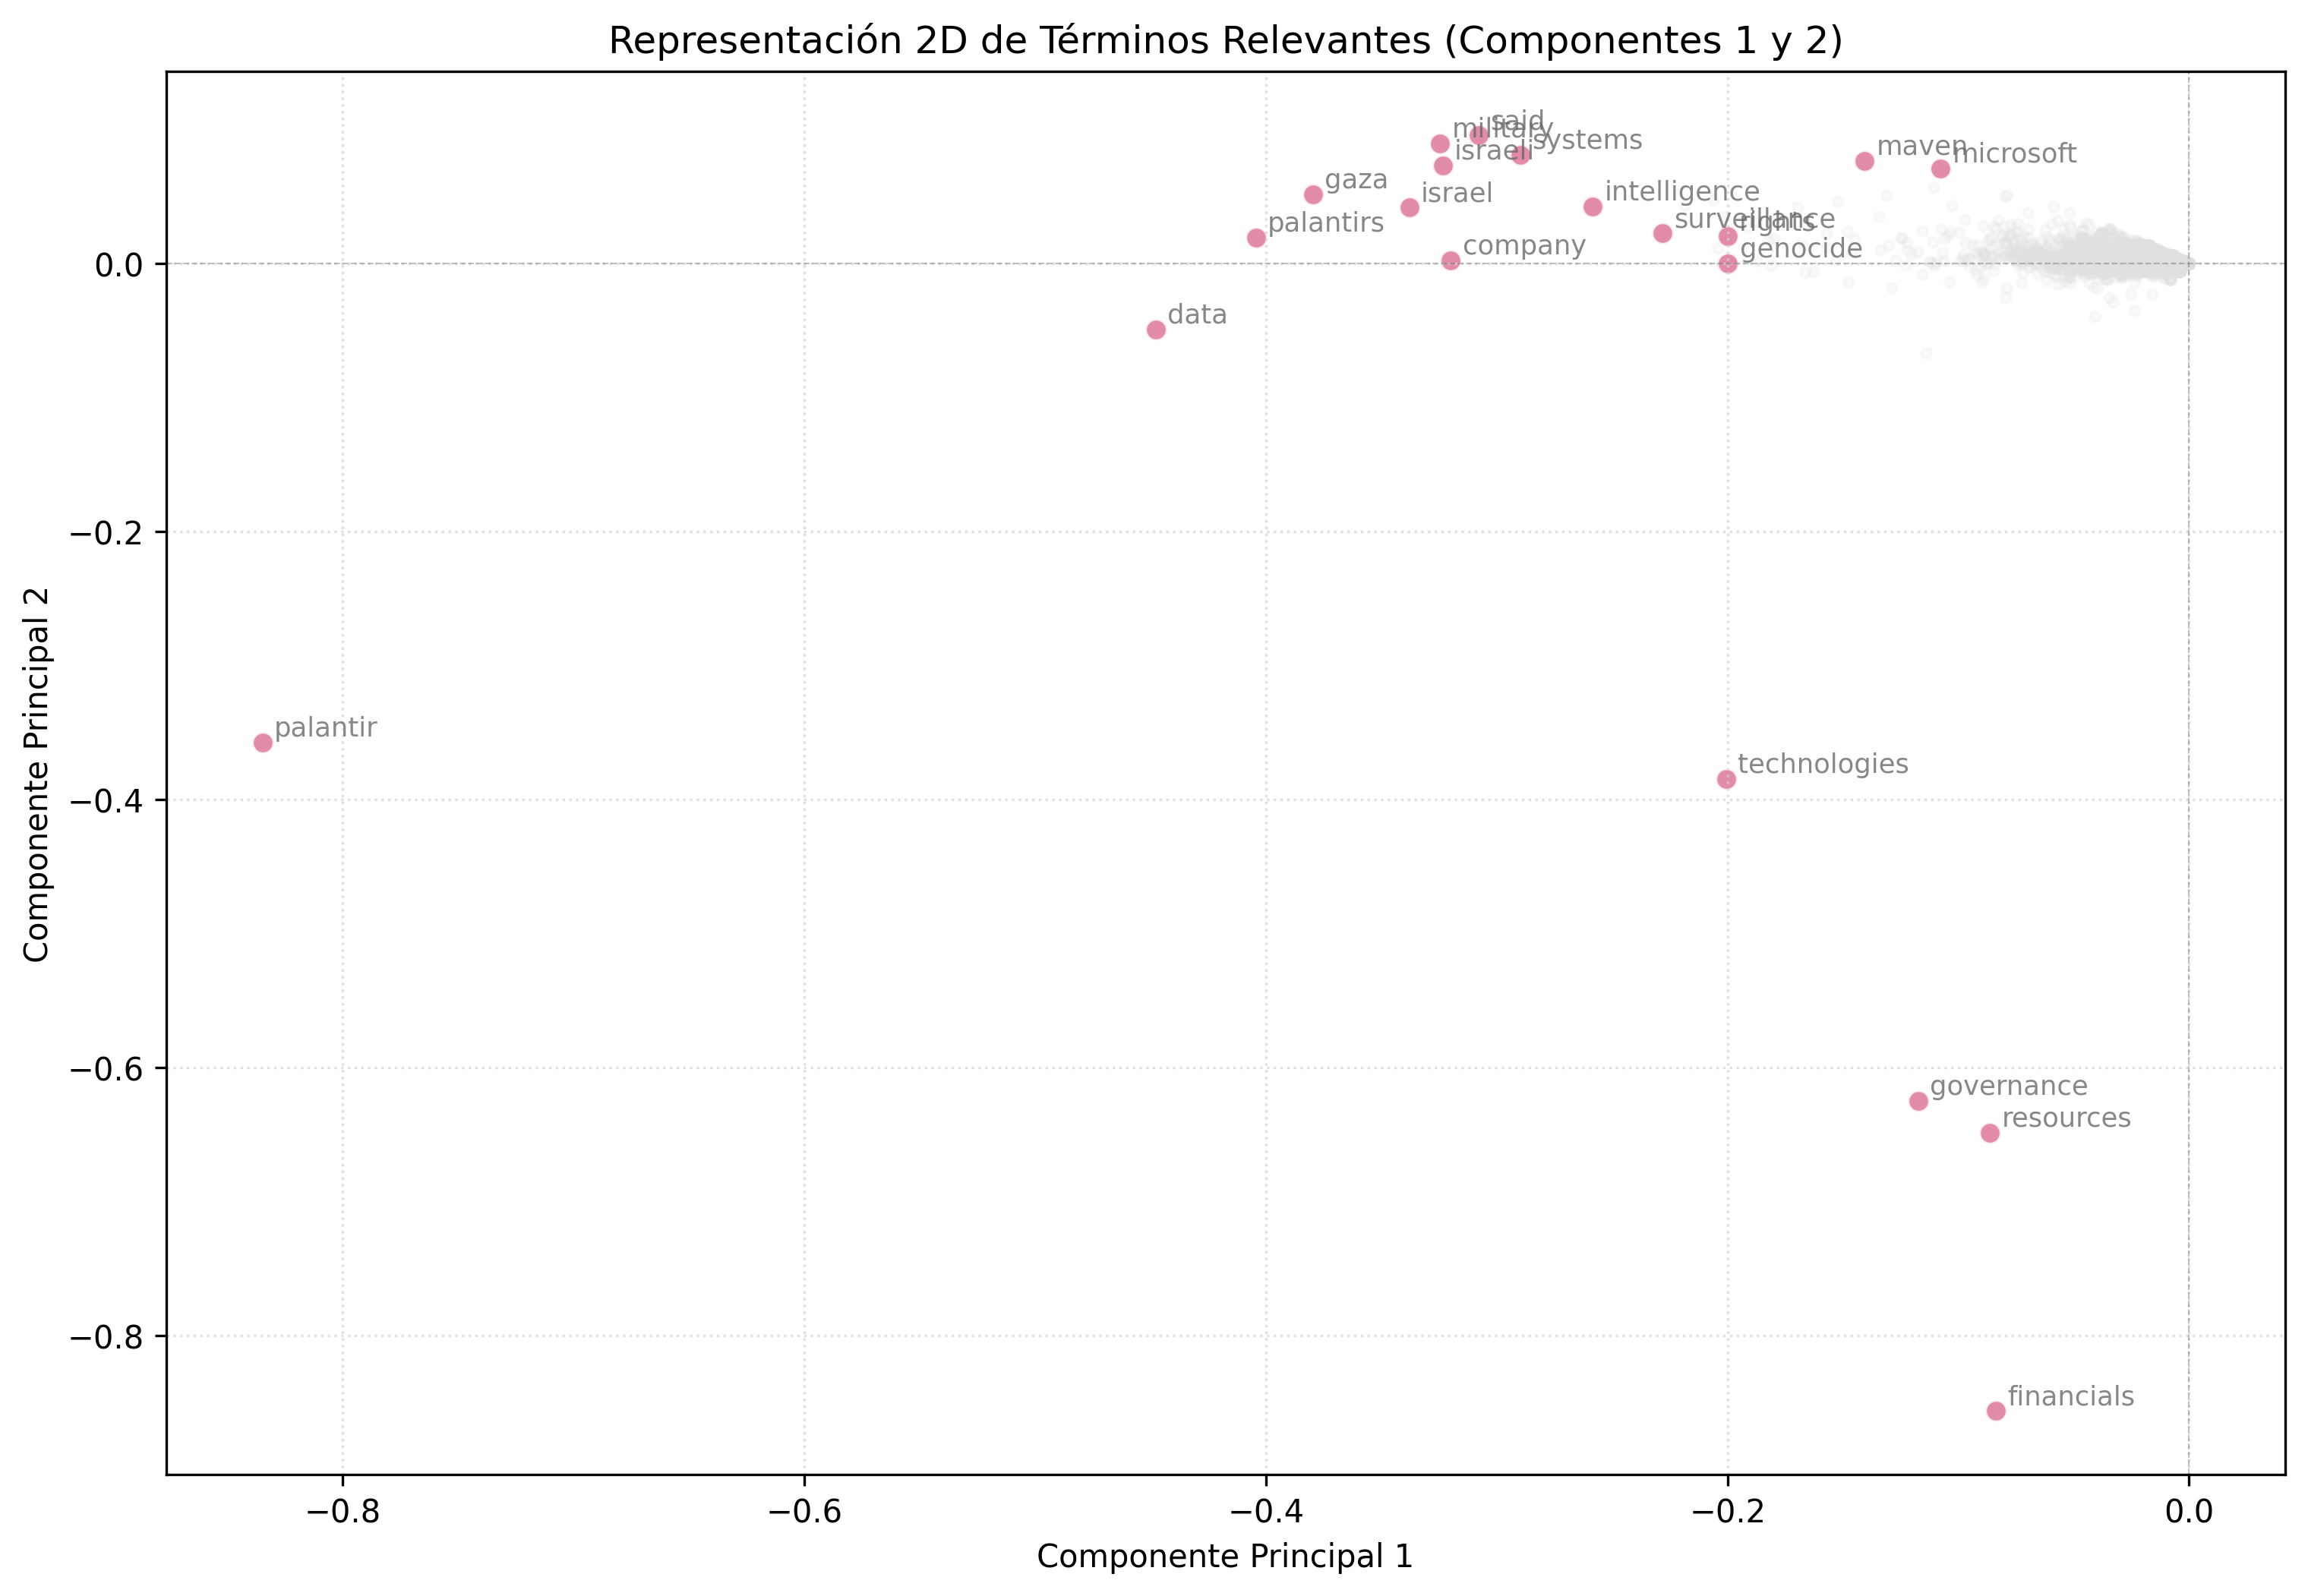